In [30]:
# =============================================================================
# ML for the Quantified Self – Master Notebook
# Gym Movements Dataset: 2 participants × 3 activities × multiple sessions (LOSO evaluation)
# Models: RF, SVM, GBM | LSTM, CNN-LSTM, TCN
# =============================================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from Python.integrations import load_gym_dataset
from Python.plots import analyze_data_distribution
from Python.windows import create_adaptive_windows
from Python.feature_engineering import engineer_robust_features
from Python.training import train_with_validation

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

# ── 1. LOAD GYM MOVEMENTS DATASET ────────────────────────────────────────────
print("Loading Gym Movements Dataset...")
raw_data = load_gym_dataset(Path("./Datasets/cropped"))
print(f"\nTotal samples  : {len(raw_data):,}")
print(f"Participants   : {sorted(raw_data['participant'].unique())}")
print(f"Activities     : {sorted(raw_data['activity_label'].unique())}")
print(f"Sessions total : {raw_data['session'].nunique()}")
print(f"Sessions/person: {raw_data.groupby('participant')['session'].nunique().to_dict()}")
print(f"Columns        : {list(raw_data.columns)}")
raw_data.head(3)


Loading Gym Movements Dataset...
Gym Movements Dataset loaded:
  Total samples : 126,745
  Participants  : ['imaan', 'richard']
  Activities    : ['elliptical', 'lat_pull', 'row', 'threadmill']
  Sessions      : 62
  Columns       : ['time', 'acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z', 'grav_x', 'grav_y', 'grav_z', 'orient_qz', 'orient_qy', 'orient_qx', 'orient_qw', 'orient_roll', 'orient_pitch', 'orient_yaw', 'mag_x', 'mag_y', 'mag_z', 'activity_label', 'participant', 'session', 'data_source']

Total samples  : 126,745
Participants   : ['imaan', 'richard']
Activities     : ['elliptical', 'lat_pull', 'row', 'threadmill']
Sessions total : 62
Sessions/person: {'imaan': 48, 'richard': 14}
Columns        : ['time', 'acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z', 'grav_x', 'grav_y', 'grav_z', 'orient_qz', 'orient_qy', 'orient_qx', 'orient_qw', 'orient_roll', 'orient_pitch', 'orient_yaw', 'mag_x', 'mag_y', 'mag_z', 'activity_label', 'participant', 'session', 'data_source

,time,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,grav_x,grav_y,grav_z,...,orient_roll,orient_pitch,orient_yaw,mag_x,mag_y,mag_z,activity_label,participant,session,data_source
0,0.000000,0.173412,-1.01202,0.230539,-0.707987,-0.479600,1.101513,-0.662412,-3.447979,9.149461,...,0.072259,0.359532,-0.233431,9.243751,28.106251,-35.343750,elliptical,imaan,0,original
1,0.019519,0.240469,-1.24172,0.357223,-0.643775,-0.588225,1.202713,-0.647469,-3.455279,9.147778,...,0.070675,0.360322,-0.244769,9.356251,27.018751,-38.737503,elliptical,imaan,0,original
2,0.039040,0.269452,-1.34355,0.356299,-0.576950,-0.688187,1.316975,-0.638452,-3.462449,9.145700,...,0.069708,0.361104,-0.255371,8.381250,27.693750,-37.425003,elliptical,imaan,0,original


In [25]:

# ── 2. MISSING VALUE HANDLING (Point 3) ──────────────────────────────────────
SENSOR_COLS = ["acc_x", "acc_y", "acc_z", "gyro_x", "gyro_y", "gyro_z", "grav_x", "grav_y", "grav_z", "orient_qz", "orient_qy", "orient_qx", "orient_qw", "orient_roll", "orient_pitch", "orient_yaw",
                    "mag_x", "mag_y", "mag_z"]

missing = raw_data[SENSOR_COLS].isnull().sum()
print("=== Missing Value Analysis ===")
print(f"Per-channel missing values:\n{missing.to_string()}")
total_missing = int(missing.sum())
print(f"\nTotal missing sensor readings: {total_missing}")

if total_missing > 0:
    print("\nApplying linear interpolation per (participant, session)...")
    raw_data[SENSOR_COLS] = (
        raw_data.groupby(["participant", "session"])[SENSOR_COLS]
        .transform(
            lambda g: g.interpolate(method="linear")
                       .ffill()
                       .bfill()
        )
    )
    remaining = int(raw_data[SENSOR_COLS].isnull().sum().sum())
    print(f"Remaining missing after interpolation: {remaining}")
else:
    print("\nNo missing values detected — dataset is complete.")


=== Missing Value Analysis ===
Per-channel missing values:
acc_x           0
acc_y           0
acc_z           0
gyro_x          2
gyro_y          2
gyro_z          2
grav_x          3
grav_y          3
grav_z          3
orient_qz       3
orient_qy       3
orient_qx       3
orient_qw       3
orient_roll     3
orient_pitch    3
orient_yaw      3
mag_x           3
mag_y           3
mag_z           3

Total missing sensor readings: 45

Applying linear interpolation per (participant, session)...
Remaining missing after interpolation: 0


=== Exploratory Data Analysis ===


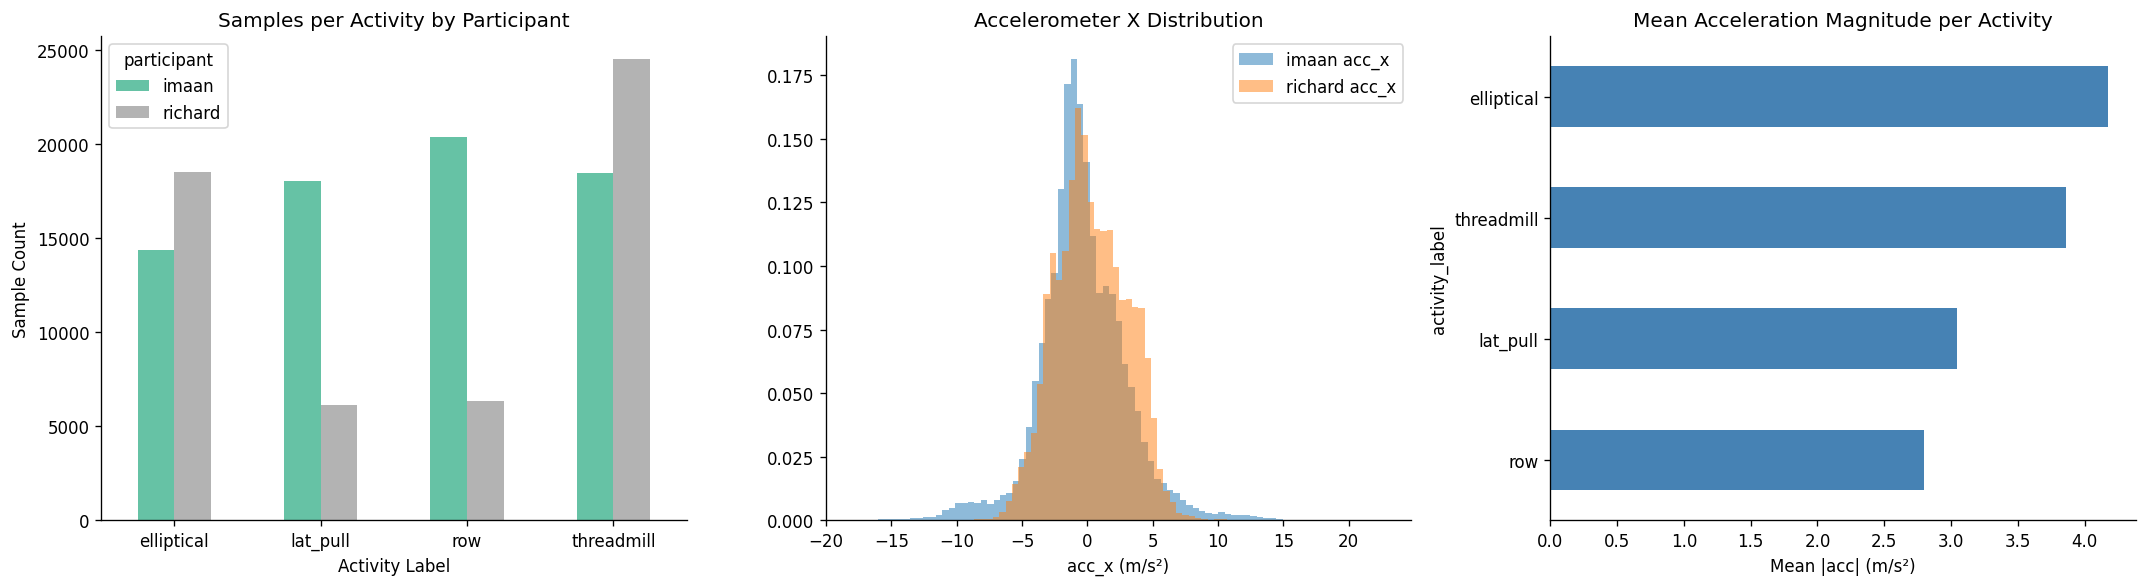


Class balance (samples per activity):
activity_label
elliptical    32857
lat_pull      24153
row           26742
threadmill    42993

Sensor statistics:
            acc_x       acc_y       acc_z      gyro_x      gyro_y      gyro_z      grav_x      grav_y      grav_z   orient_qz   orient_qy   orient_qx   orient_qw  orient_roll  orient_pitch  orient_yaw       mag_x       mag_y       mag_z
count  126745.000  126745.000  126745.000  126745.000  126745.000  126745.000  126745.000  126745.000  126745.000  126745.000  126745.000  126745.000  126745.000   126745.000    126745.000  126745.000  126745.000  126745.000  126745.000
mean       -0.062      -0.214       0.021       0.013      -0.094       0.115      -1.398      -3.489       4.448      -0.042       0.103      -0.185       0.706        0.201         0.398      -0.035       0.433      30.343     -21.282
std         3.152       1.914       1.944       2.153       1.924       1.799       6.553       3.336       2.849       0.412       0.3

In [26]:

# ── 3. EXPLORATORY DATA ANALYSIS (Point 2) ───────────────────────────────────
print("=== Exploratory Data Analysis ===")

# Activity label distribution
if "activity_label" in raw_data.columns:
    act_col = "activity_label"
elif "activity" in raw_data.columns:
    act_col = "activity"
else:
    raise RuntimeError("No activity label column found in raw_data.")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Samples per activity
act_counts = raw_data.groupby([act_col, "participant"]).size().unstack(fill_value=0)
act_counts.plot(kind="bar", ax=axes[0], colormap="Set2")
axes[0].set_title("Samples per Activity by Participant")
axes[0].set_xlabel("Activity Label")
axes[0].set_ylabel("Sample Count")
axes[0].tick_params(axis="x", rotation=0)

# (b) Accelerometer distributions
for p, ls in zip(sorted(raw_data["participant"].unique()), ["-", "--"]):
    pdata = raw_data[raw_data["participant"] == p]
    axes[1].hist(pdata["acc_x"], bins=80, alpha=0.5, density=True, label=f"{p} acc_x", linestyle=ls)
axes[1].set_title("Accelerometer X Distribution")
axes[1].set_xlabel("acc_x (m/s²)")
axes[1].legend()

# (c) Gyroscope by activity (mean acc magnitude)
raw_data["acc_mag"] = np.sqrt(
    raw_data["acc_x"]**2 + raw_data["acc_y"]**2 + raw_data["acc_z"]**2
)
act_mag = raw_data.groupby(act_col)["acc_mag"].mean().sort_values()
act_mag.plot(kind="barh", ax=axes[2], color="steelblue")
axes[2].set_title("Mean Acceleration Magnitude per Activity")
axes[2].set_xlabel("Mean |acc| (m/s²)")

plt.tight_layout()
plt.savefig("./Plots/field_data_eda.png", dpi=150, bbox_inches="tight")
plt.show()

# Class balance report
print("\nClass balance (samples per activity):")
print(raw_data[act_col].value_counts().sort_index().to_string())
print(f"\nSensor statistics:\n{raw_data[SENSOR_COLS].describe().round(3).to_string()}")


In [27]:

# ── 4. WINDOWING & FEATURE ENGINEERING (Point 4) ─────────────────────────────
print("=== Windowing ===")
windowed_data = create_adaptive_windows(
    raw_data,
    min_window_size=64,
    preferred_window_size=128,   # 2.56 s @ 50 Hz
    overlap_ratio=0.5,
)

print("\n=== Feature Engineering ===")
features, labels, feature_names, metadata = engineer_robust_features(
    windowed_data, sampling_rate=50
)

print(f"\nFeature matrix shape: {features.shape}")
print(f"Label distribution  : {dict(zip(*np.unique(labels, return_counts=True)))}")

participants = np.array([m["participant"] for m in metadata])
print(f"Windows per participant: "
      f"{dict(zip(*np.unique(participants, return_counts=True)))}")


=== Windowing ===

Window creation summary:
  Full-size windows: 1888
  Adaptive windows: 0
  Rejected segments: 0
  Total windows: 1888

=== Feature Engineering ===
  Processing window 0/1888...
  Processing window 100/1888...
  Processing window 200/1888...
  Processing window 300/1888...
  Processing window 400/1888...
  Processing window 500/1888...
  Processing window 600/1888...
  Processing window 700/1888...
  Processing window 800/1888...
  Processing window 900/1888...
  Processing window 1000/1888...
  Processing window 1100/1888...
  Processing window 1200/1888...
  Processing window 1300/1888...
  Processing window 1400/1888...
  Processing window 1500/1888...
  Processing window 1600/1888...
  Processing window 1700/1888...
  Processing window 1800/1888...

Feature matrix shape: (1888, 145)
Label distribution  : {np.str_('elliptical'): np.int64(490), np.str_('lat_pull'): np.int64(355), np.str_('row'): np.int64(393), np.str_('threadmill'): np.int64(650)}
Windows per partic

['acc_x_mean', 'acc_x_std', 'acc_x_max', 'acc_x_min', 'acc_x_median', 'acc_x_skew', 'acc_x_kurtosis', 'acc_x_q25', 'acc_x_q75', 'acc_x_q90', 'acc_x_q10', 'acc_x_mean_abs', 'acc_x_rms', 'acc_x_range', 'acc_x_zcr', 'acc_x_spectral_centroid', 'acc_x_spectral_spread', 'acc_x_low_band_power', 'acc_x_mid_band_power', 'acc_x_high_band_power', 'acc_x_spectral_entropy', 'acc_y_mean', 'acc_y_std', 'acc_y_max', 'acc_y_min', 'acc_y_median', 'acc_y_skew', 'acc_y_kurtosis', 'acc_y_q25', 'acc_y_q75', 'acc_y_q90', 'acc_y_q10', 'acc_y_mean_abs', 'acc_y_rms', 'acc_y_range', 'acc_y_zcr', 'acc_y_spectral_centroid', 'acc_y_spectral_spread', 'acc_y_low_band_power', 'acc_y_mid_band_power', 'acc_y_high_band_power', 'acc_y_spectral_entropy', 'acc_z_mean', 'acc_z_std', 'acc_z_max', 'acc_z_min', 'acc_z_median', 'acc_z_skew', 'acc_z_kurtosis', 'acc_z_q25', 'acc_z_q75', 'acc_z_q90', 'acc_z_q10', 'acc_z_mean_abs', 'acc_z_rms', 'acc_z_range', 'acc_z_zcr', 'acc_z_spectral_centroid', 'acc_z_spectral_spread', 'acc_z_lo

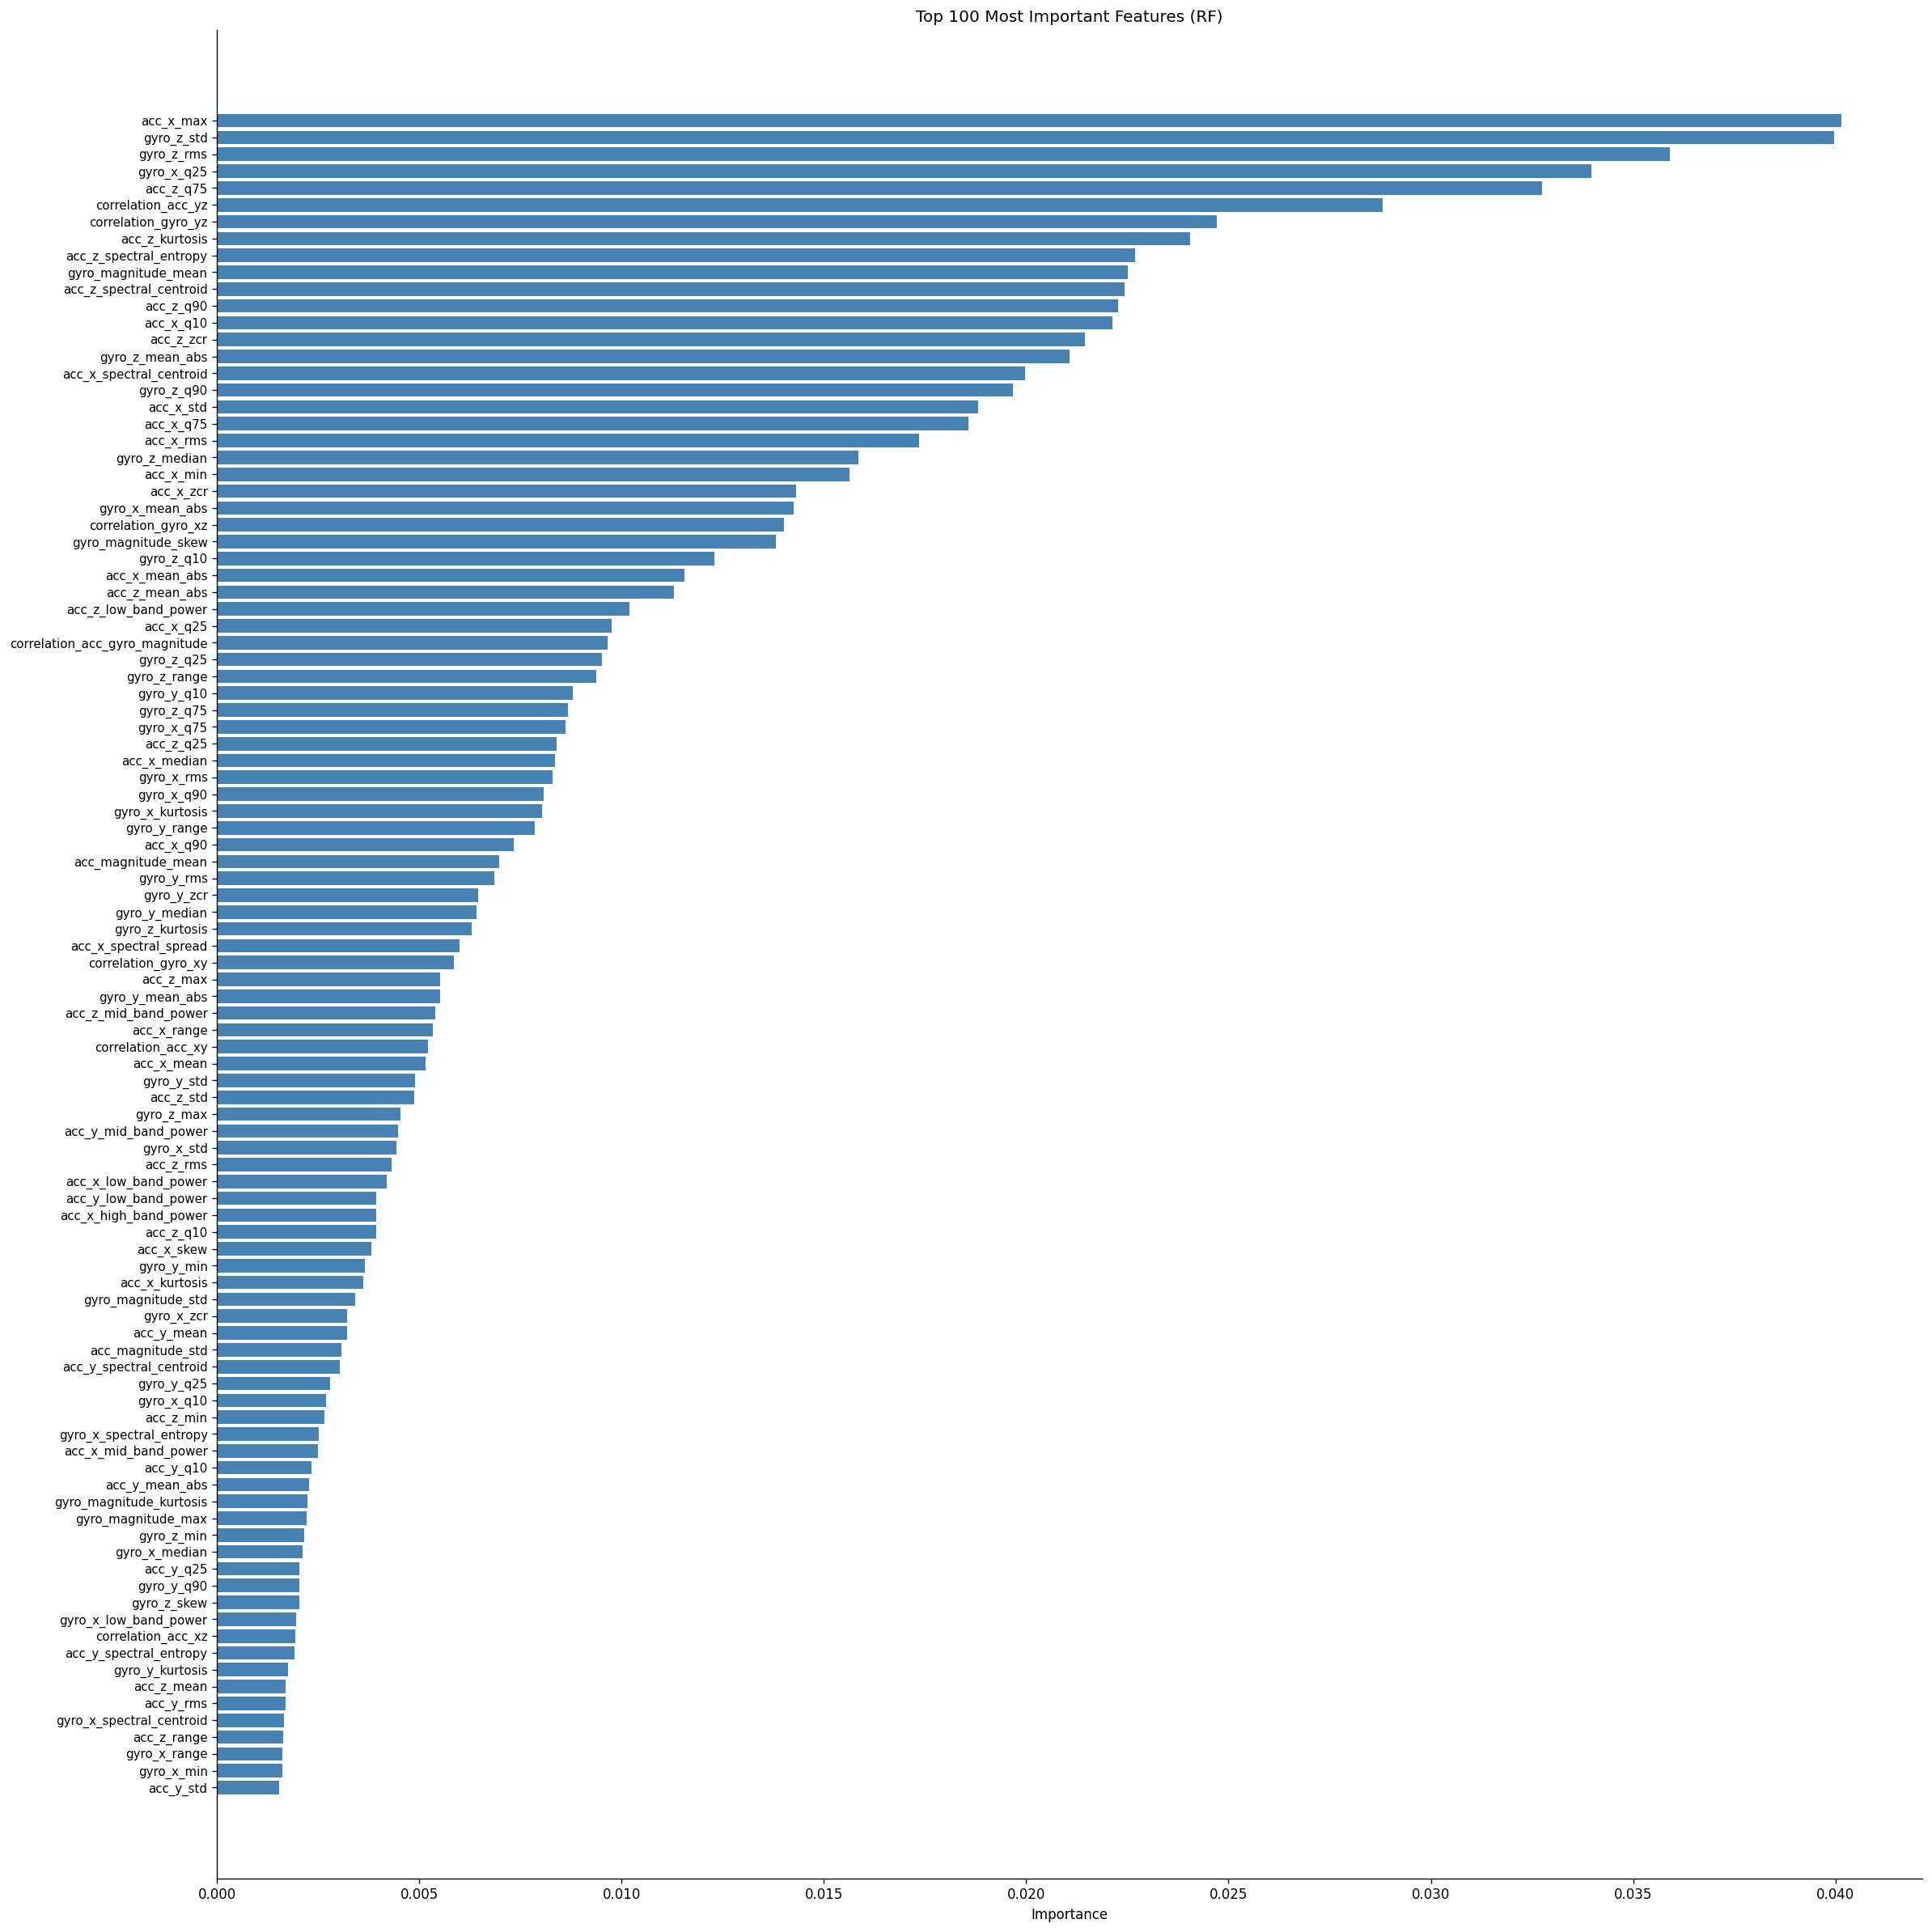

Top 5 features:
  1. acc_x_max                                0.0401
  2. gyro_z_std                               0.0400
  3. gyro_z_rms                               0.0359
  4. gyro_x_q25                               0.0340
  5. acc_z_q75                                0.0327


In [32]:
# ── 5. FEATURE IMPORTANCE (Point 4) ──────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

print(feature_names)
# Quick RF for feature importance (stratified, not the final eval split)
scaler_tmp = StandardScaler()
feat_scaled = scaler_tmp.fit_transform(features)

rf_tmp = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_tmp.fit(feat_scaled, labels)

importances = rf_tmp.feature_importances_
top_k = 100
top_idx = np.argsort(importances)[-top_k:][::-1]

fig, ax = plt.subplots(figsize=(20, 20))
ax.barh(
    range(top_k),
    importances[top_idx][::-1],
    color="steelblue",
)
ax.set_yticks(range(top_k))
ax.set_yticklabels([feature_names[i] for i in top_idx][::-1], fontsize=9)
ax.set_xlabel("Importance")
ax.set_title(f"Top {top_k} Most Important Features (RF)")
plt.tight_layout()
plt.savefig("./Plots/field_data_feature_importances.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Top 5 features:")
for rank, idx in enumerate(top_idx[:5], 1):
    print(f"  {rank}. {feature_names[idx]:40s} {importances[idx]:.4f}")



  RF – LOSO

=== Training [RF] with [loso] validation ===

  LOSO fold: test=imaan  (train=919, test=1234)

Test Accuracy [RF test=imaan]: 0.4011
              precision    recall  f1-score   support

  elliptical       0.65      0.15      0.24       250
    lat_pull       0.08      0.02      0.04       332
         row       0.92      0.42      0.58       346
  threadmill       0.33      0.99      0.49       306

    accuracy                           0.40      1234
   macro avg       0.50      0.40      0.34      1234
weighted avg       0.49      0.40      0.34      1234



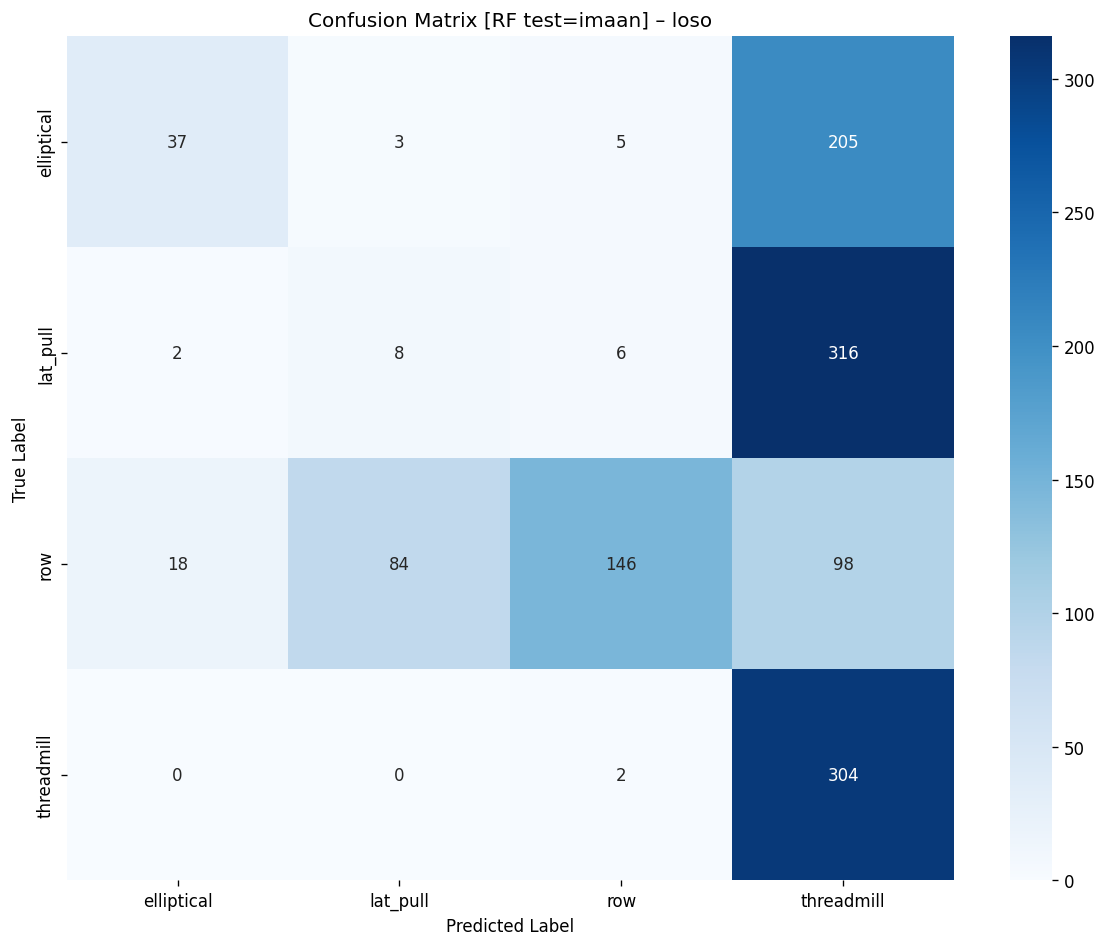


  LOSO fold: test=richard  (train=1234, test=919)

Test Accuracy [RF test=richard]: 0.5811
              precision    recall  f1-score   support

  elliptical       0.99      0.25      0.39       300
    lat_pull       0.11      0.07      0.08       105
         row       0.26      0.96      0.41       119
  threadmill       0.99      0.86      0.92       395

    accuracy                           0.58       919
   macro avg       0.59      0.53      0.45       919
weighted avg       0.79      0.58      0.59       919



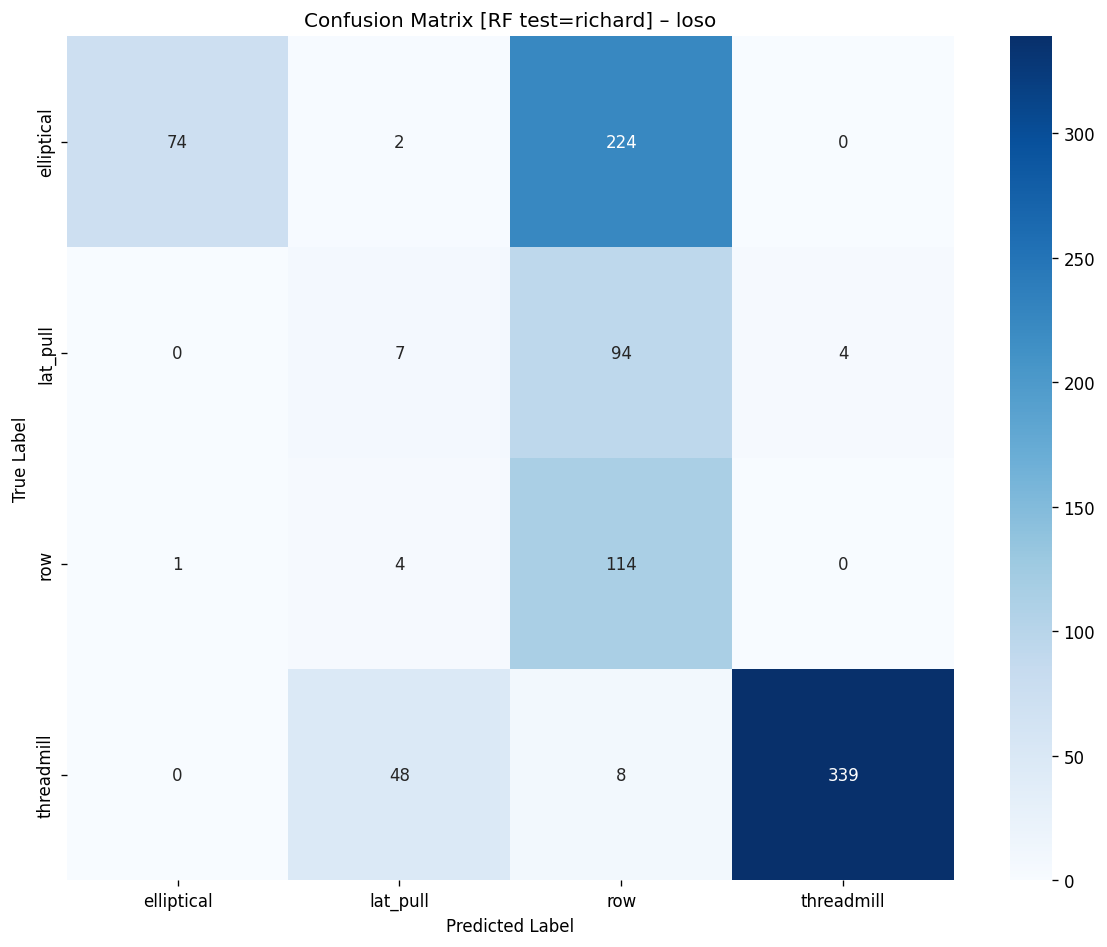


  LOSO Mean Accuracy (RF): 0.4911
  Per-fold: {'imaan': 0.4011345218800648, 'richard': 0.5810663764961915}

  SVM – LOSO

=== Training [SVM] with [loso] validation ===

  LOSO fold: test=imaan  (train=919, test=1234)

Test Accuracy [SVM test=imaan]: 0.3128
              precision    recall  f1-score   support

  elliptical       0.33      0.08      0.13       250
    lat_pull       0.42      0.74      0.54       332
         row       0.09      0.12      0.10       346
  threadmill       0.65      0.26      0.37       306

    accuracy                           0.31      1234
   macro avg       0.37      0.30      0.29      1234
weighted avg       0.37      0.31      0.29      1234



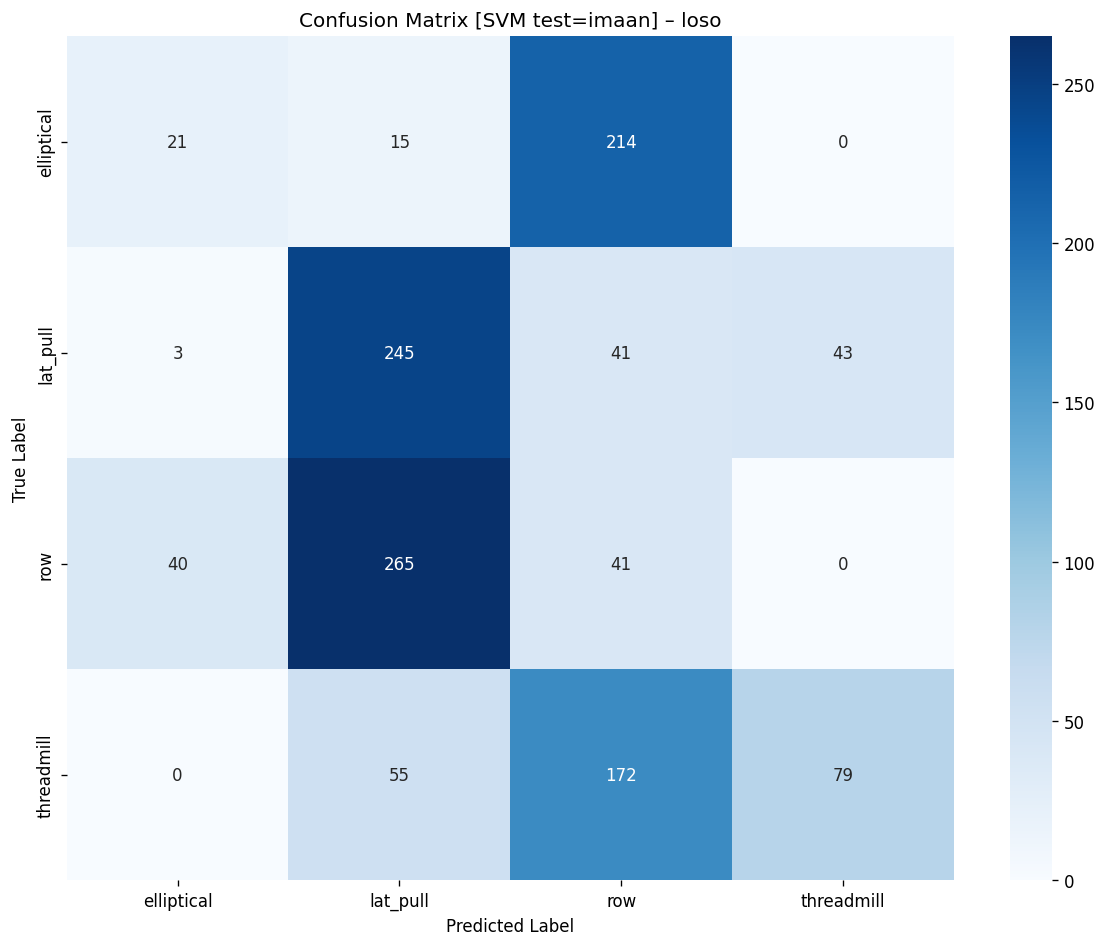


  LOSO fold: test=richard  (train=1234, test=919)

Test Accuracy [SVM test=richard]: 0.4886
              precision    recall  f1-score   support

  elliptical       0.48      0.68      0.56       300
    lat_pull       0.01      0.02      0.02       105
         row       0.15      0.17      0.16       119
  threadmill       1.00      0.56      0.72       395

    accuracy                           0.49       919
   macro avg       0.41      0.36      0.36       919
weighted avg       0.61      0.49      0.52       919



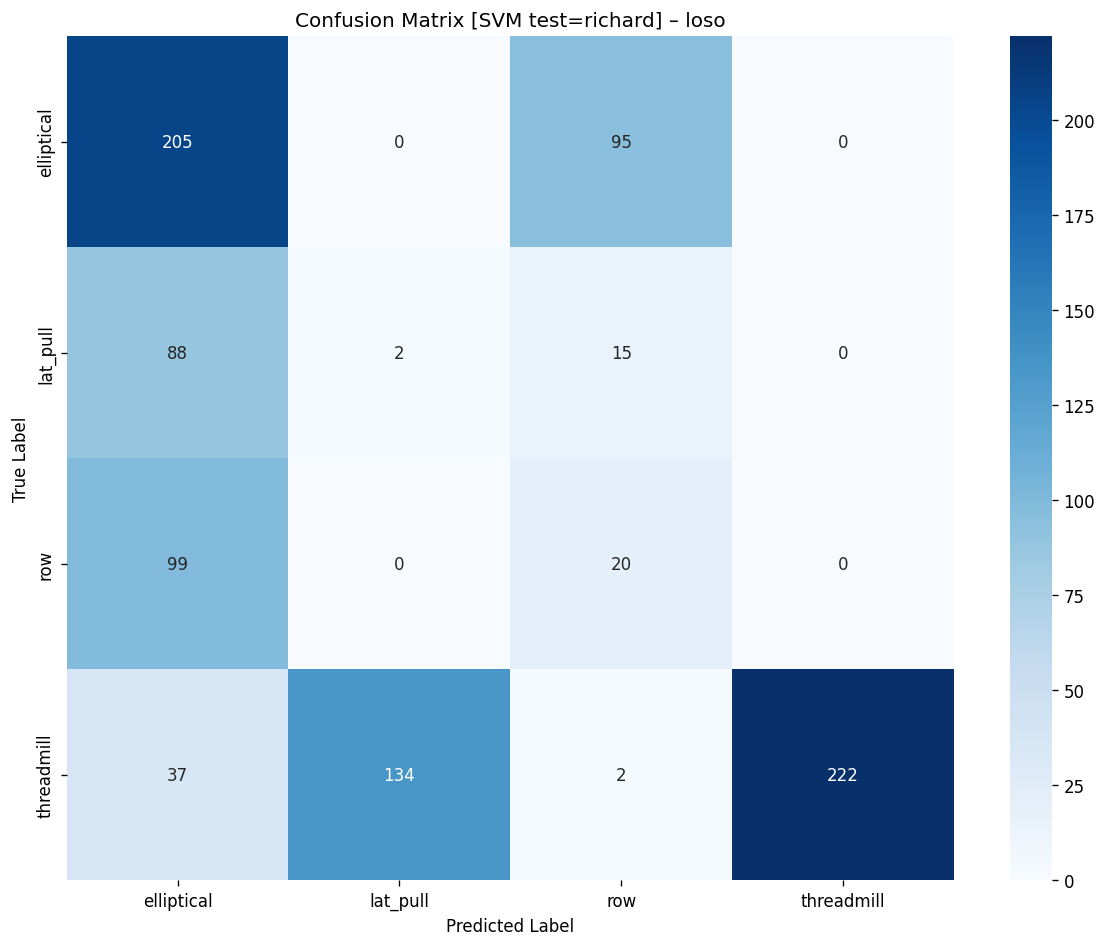


  LOSO Mean Accuracy (SVM): 0.4007
  Per-fold: {'imaan': 0.31280388978930307, 'richard': 0.4885745375408052}

  GBM – LOSO

=== Training [GBM] with [loso] validation ===

  LOSO fold: test=imaan  (train=919, test=1234)

Test Accuracy [GBM test=imaan]: 0.5859
              precision    recall  f1-score   support

  elliptical       0.79      0.74      0.77       250
    lat_pull       0.37      0.02      0.04       332
         row       0.57      0.83      0.68       346
  threadmill       0.51      0.79      0.62       306

    accuracy                           0.59      1234
   macro avg       0.56      0.60      0.53      1234
weighted avg       0.55      0.59      0.51      1234



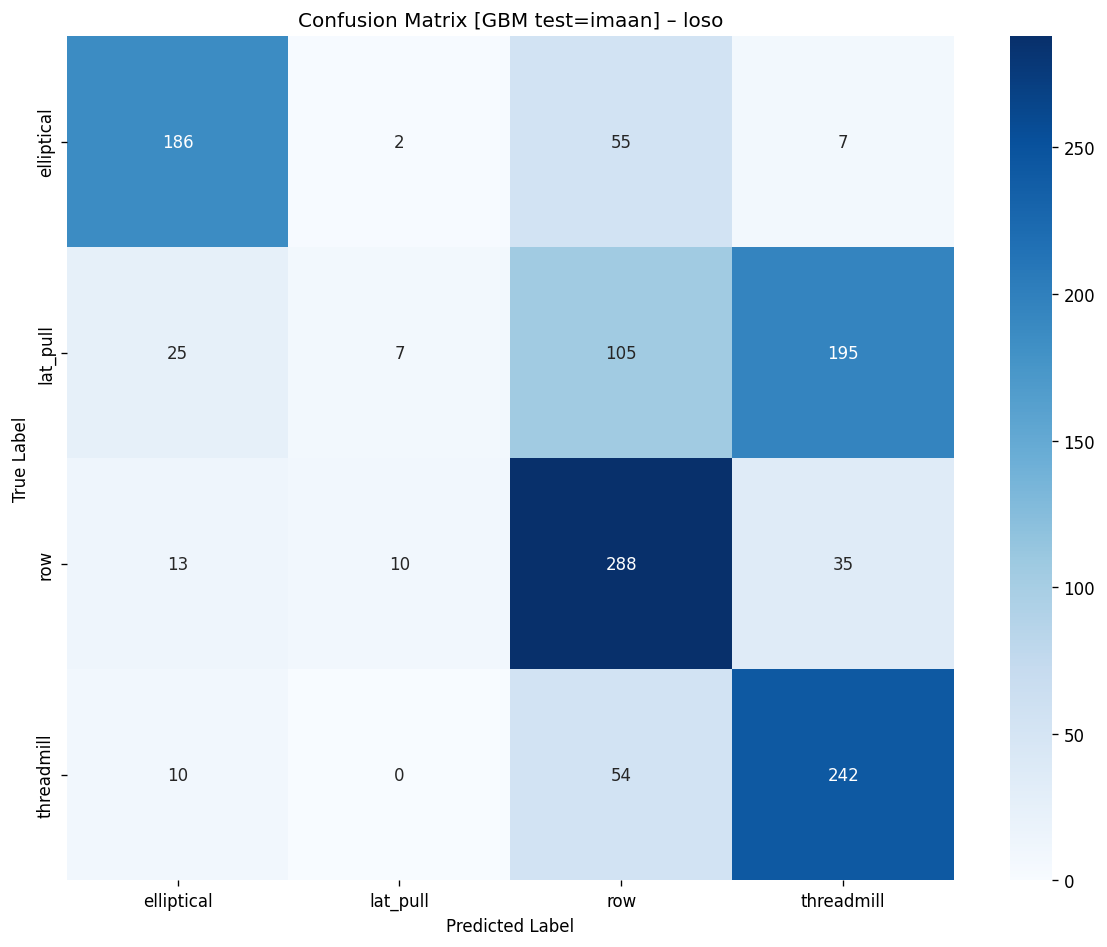


  LOSO fold: test=richard  (train=1234, test=919)

Test Accuracy [GBM test=richard]: 0.5147
              precision    recall  f1-score   support

  elliptical       1.00      0.00      0.01       300
    lat_pull       0.38      0.31      0.34       105
         row       0.21      0.61      0.31       119
  threadmill       0.76      0.93      0.83       395

    accuracy                           0.51       919
   macro avg       0.59      0.46      0.37       919
weighted avg       0.72      0.51      0.44       919



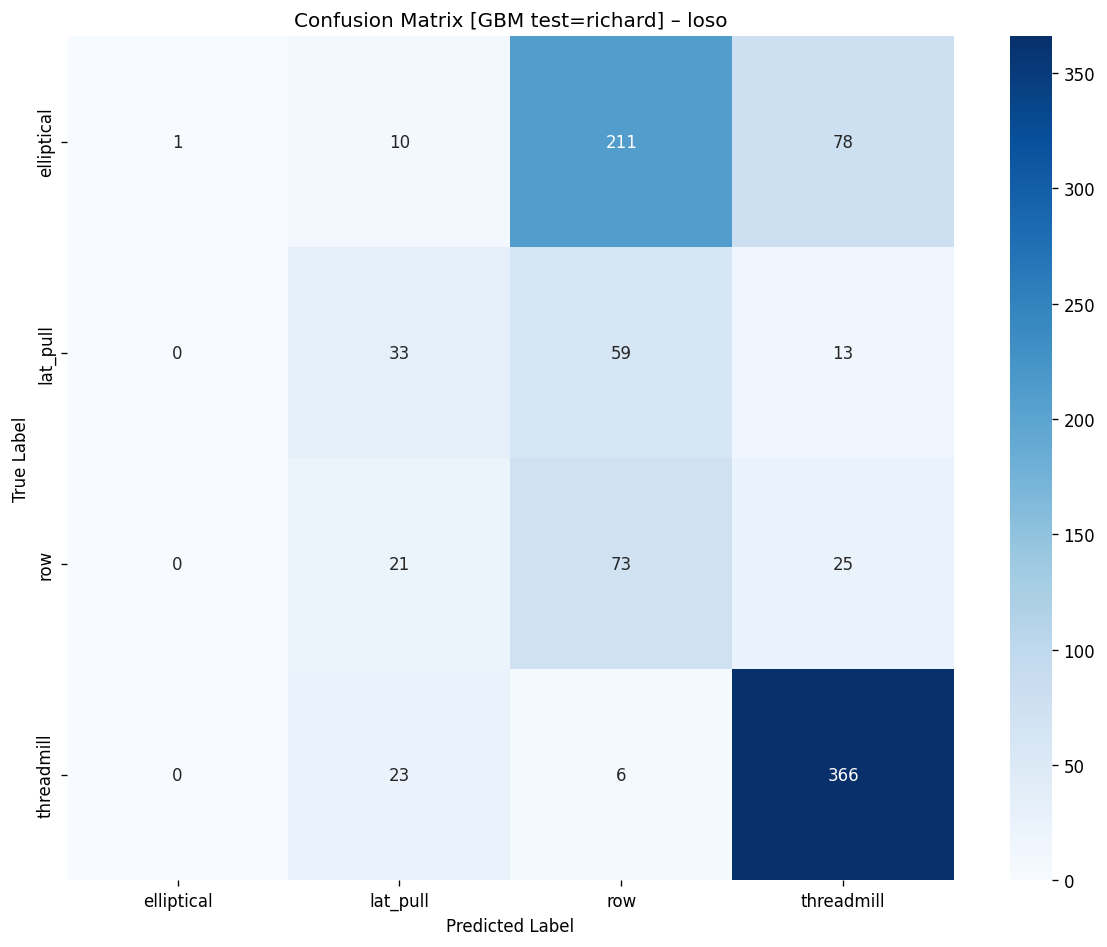


  LOSO Mean Accuracy (GBM): 0.5503
  Per-fold: {'imaan': 0.5858995137763371, 'richard': 0.514689880304679}

=== Classical Model LOSO Summary ===
  RF  : mean LOSO accuracy = 0.4911  | per-fold = {'imaan': 0.4011345218800648, 'richard': 0.5810663764961915}
  SVM : mean LOSO accuracy = 0.4007  | per-fold = {'imaan': 0.31280388978930307, 'richard': 0.4885745375408052}
  GBM : mean LOSO accuracy = 0.5503  | per-fold = {'imaan': 0.5858995137763371, 'richard': 0.514689880304679}


In [15]:

# ── 6. CLASSICAL ML – LOSO EVALUATION (Point 5) ──────────────────────────────
# Evaluation split: Leave-One-Subject-Out
# Train on participant A → test on participant B, and vice versa.
# This measures generalisation to an unseen person, as required by the brief.

classical_results = {}
classical_models = {}

for model_type in ["rf", "svm", "gbm"]:
    print(f"\n{'='*60}")
    print(f"  {model_type.upper()} – LOSO")
    print(f"{'='*60}")
    trained_model, trained_scaler, res = train_with_validation(
        features, labels, feature_names, metadata,
        validation_strategy="loso",
        model_type=model_type,
    )
    classical_results[model_type] = res
    classical_models[model_type] = (trained_model, trained_scaler)

rf_model = classical_models["rf"][0]

print("\n=== Classical Model LOSO Summary ===")
for mt, res in classical_results.items():
    print(f"  {mt.upper():4s}: mean LOSO accuracy = {res['mean_accuracy']:.4f}  "
          f"| per-fold = {res['per_fold_accuracy']}")



Gym Movements Deep Learning Pipeline (LOSO Evaluation)

Loading Gym Movements Dataset...
Gym Movements Dataset loaded:
  Total samples : 143,547
  Participants  : ['imaan', 'richard']
  Activities    : ['elliptical', 'lat_pull', 'row', 'threadmill']
  Sessions      : 62
  Columns       : ['time', 'acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z', 'grav_x', 'grav_y', 'grav_z', 'orient_qz', 'orient_qy', 'orient_qx', 'orient_qw', 'orient_roll', 'orient_pitch', 'orient_yaw', 'mag_x', 'mag_y', 'mag_z', 'activity_label', 'participant', 'session', 'data_source']
Total samples: 143547
Participants: ['imaan', 'richard']
Activities: ['elliptical', 'lat_pull', 'row', 'threadmill']

=== Missing Value Analysis ===
Missing values per channel:
acc_x      0
acc_y      0
acc_z      0
gyro_x    25
gyro_y    25
gyro_z    25

Total missing: 75 — applying linear interpolation per session

Creating adaptive windows...

Window creation summary:
  Full-size windows: 2153
  Adaptive windows: 0
  Rejecte

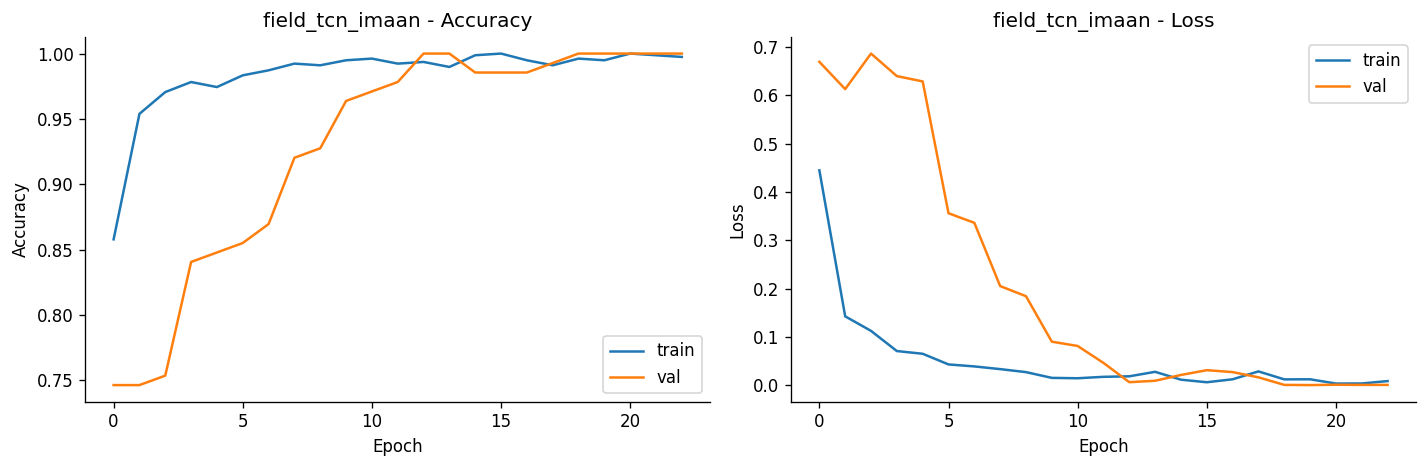


Training LSTM (test=imaan)...
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 146ms/step - accuracy: 0.5813 - loss: 1.0276 - val_accuracy: 0.7536 - val_loss: 0.6228 - learning_rate: 0.0010
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 301ms/step - accuracy: 0.7977 - loss: 0.5536 - val_accuracy: 0.8551 - val_loss: 0.3290 - learning_rate: 0.0010
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 312ms/step - accuracy: 0.8540 - loss: 0.3570 - val_accuracy: 0.8478 - val_loss: 0.3610 - learning_rate: 0.0010
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 329ms/step - accuracy: 0.8451 - loss: 0.3684 - val_accuracy: 0.7681 - val_loss: 0.9879 - learning_rate: 0.0010
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 304ms/step - accuracy: 0.8720 - loss: 0.3252 - val_accuracy: 0.8623 - val_loss: 0.2422 - learning_rate: 0.0010
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 279ms/step - accuracy: 0.8656 - loss: 0.2962 - val_accuracy: 0.8696 - val_loss: 0.2404 - learning_rate: 0.0010
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 337ms/step - acc

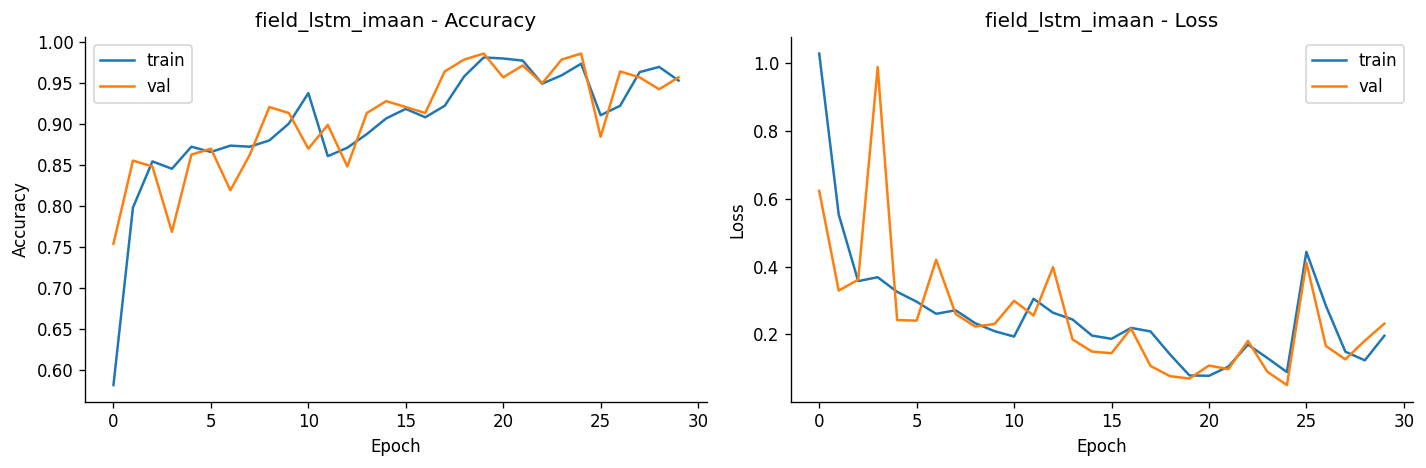


Training CNN_LSTM (test=imaan)...
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - accuracy: 0.5877 - loss: 1.1246 - val_accuracy: 0.7391 - val_loss: 1.0078 - learning_rate: 0.0010
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.8425 - loss: 0.4876 - val_accuracy: 0.7391 - val_loss: 1.3077 - learning_rate: 0.0010
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.8809 - loss: 0.2750 - val_accuracy: 0.7536 - val_loss: 1.3642 - learning_rate: 0.0010
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.9219 - loss: 0.1986 - val_accuracy: 0.9348 - val_loss: 0.2945 - learning_rate: 0.0010
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - accuracy: 0.9411 - loss: 0.1577 - val_accuracy: 0.9348 - val_loss: 0.2291 - learning_rate: 0.0010
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.9667 - loss: 0.0962 - val_accuracy: 0.8986 - val_loss: 0.4339 - learning_rate: 0.0010
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accura

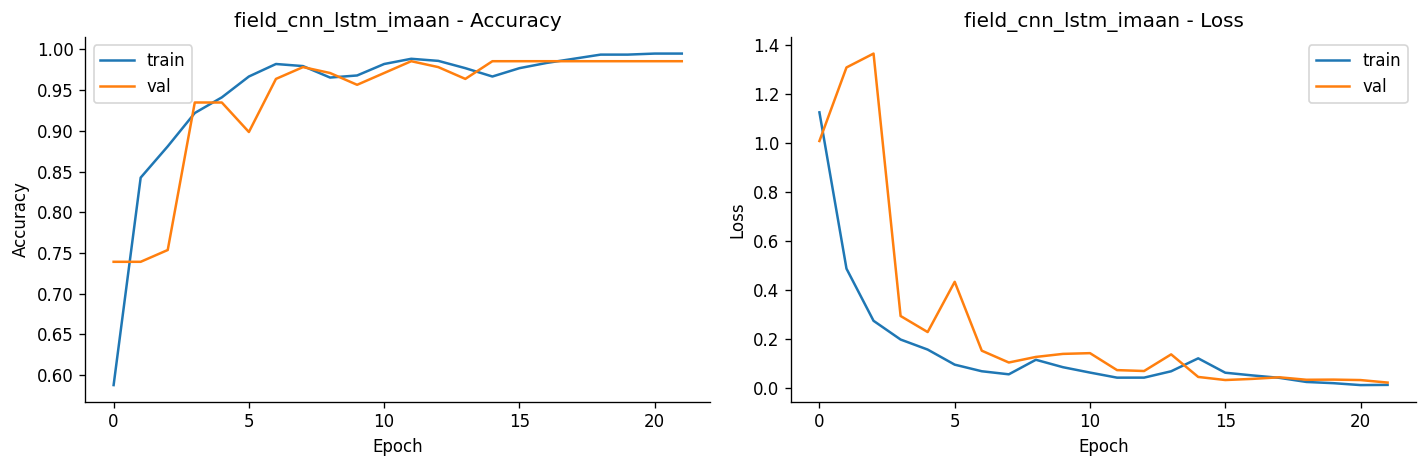


LOSO fold: TEST participant = richard
Train samples: 1234, Test samples: 919

Training TCN (test=richard)...
Epoch 1/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 12s 74ms/step - accuracy: 0.8368 - loss: 0.5142 - val_accuracy: 0.7043 - val_loss: 0.8670 - learning_rate: 0.0010
Epoch 2/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - accuracy: 0.9256 - loss: 0.2516 - val_accuracy: 0.9086 - val_loss: 0.4138 - learning_rate: 0.0010
Epoch 3/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - accuracy: 0.9256 - loss: 0.2195 - val_accuracy: 0.8763 - val_loss: 0.3627 - learning_rate: 0.0010
Epoch 4/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.9303 - loss: 0.2286 - val_accuracy: 0.9301 - val_loss: 0.2316 - learning_rate: 0.0010
Epoch 5/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.9427 - loss: 0.1675 - val_accuracy: 0.9462 - val_loss: 0.2021 - learning_rate: 0.0010
Epoch 6/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.9399 - loss: 0.1729 - val_accuracy: 0.9140 - val_loss: 0.2127 - learn

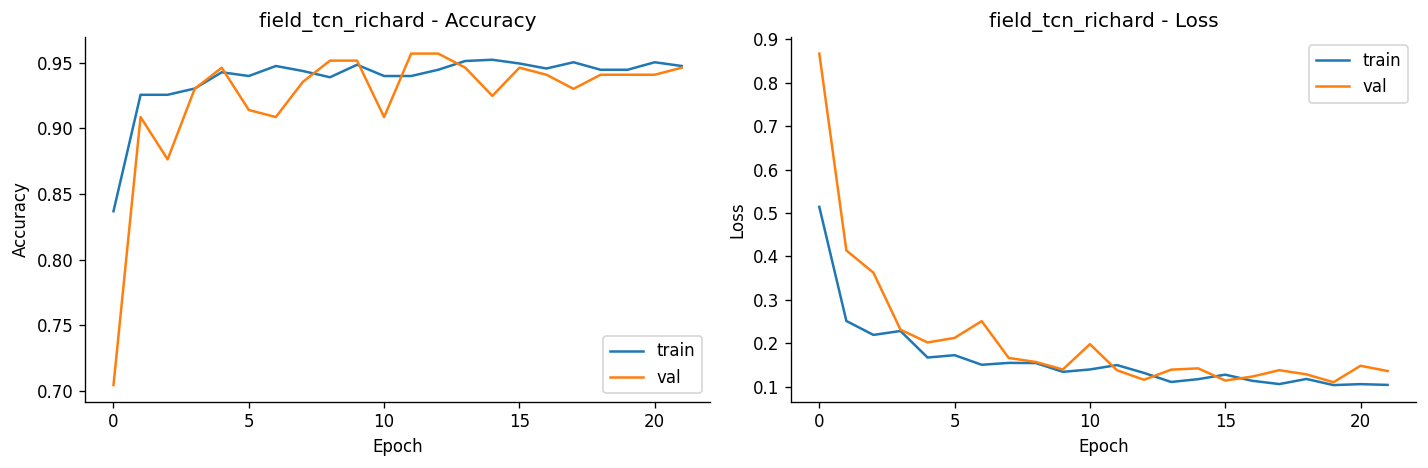


Training LSTM (test=richard)...
Epoch 1/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 10s 197ms/step - accuracy: 0.4275 - loss: 1.2036 - val_accuracy: 0.5968 - val_loss: 0.9385 - learning_rate: 0.0010
Epoch 2/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 11s 328ms/step - accuracy: 0.7195 - loss: 0.8039 - val_accuracy: 0.5591 - val_loss: 1.2366 - learning_rate: 0.0010
Epoch 3/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 7s 208ms/step - accuracy: 0.5735 - loss: 1.0108 - val_accuracy: 0.6129 - val_loss: 0.9485 - learning_rate: 0.0010
Epoch 4/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 11s 337ms/step - accuracy: 0.7433 - loss: 0.7560 - val_accuracy: 0.8495 - val_loss: 0.5165 - learning_rate: 0.0010
Epoch 5/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 10s 288ms/step - accuracy: 0.8426 - loss: 0.5446 - val_accuracy: 0.9194 - val_loss: 0.3025 - learning_rate: 0.0010
Epoch 6/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 8s 248ms/step - accuracy: 0.8693 - loss: 0.4351 - val_accuracy: 0.7796 - val_loss: 0.5296 - learning_rate: 0.0010
Epoch 7/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 10s 308ms/ste

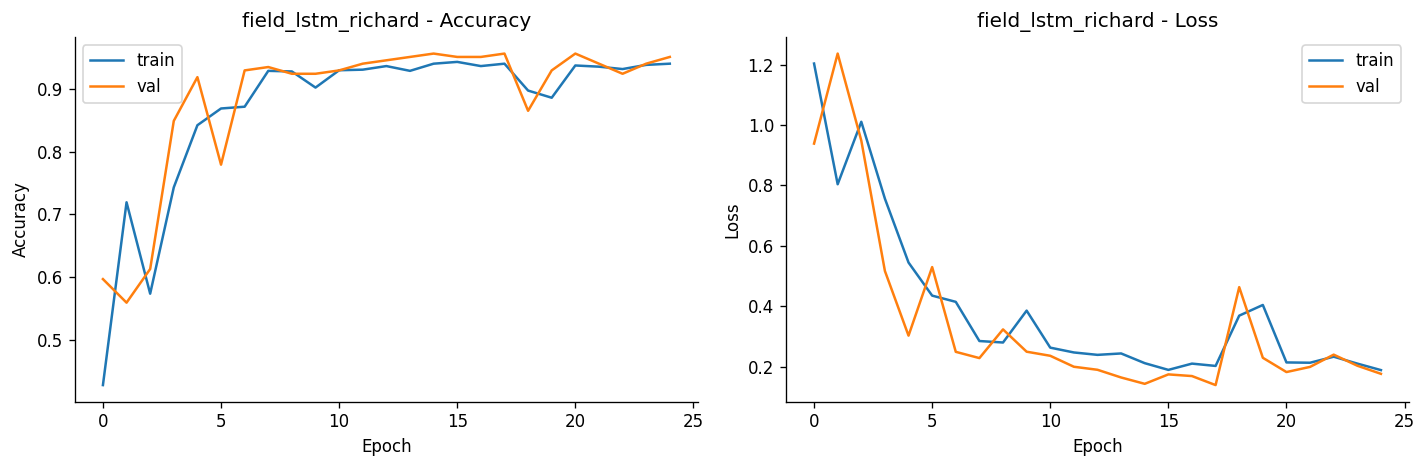


Training CNN_LSTM (test=richard)...
Epoch 1/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - accuracy: 0.5563 - loss: 1.1438 - val_accuracy: 0.4677 - val_loss: 1.1097 - learning_rate: 0.0010
Epoch 2/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.8406 - loss: 0.5833 - val_accuracy: 0.9086 - val_loss: 0.4299 - learning_rate: 0.0010
Epoch 3/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.9065 - loss: 0.3544 - val_accuracy: 0.8871 - val_loss: 0.4745 - learning_rate: 0.0010
Epoch 4/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.9284 - loss: 0.2748 - val_accuracy: 0.9355 - val_loss: 0.2255 - learning_rate: 0.0010
Epoch 5/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.9294 - loss: 0.2529 - val_accuracy: 0.8978 - val_loss: 0.3232 - learning_rate: 0.0010
Epoch 6/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 105ms/step - accuracy: 0.8941 - loss: 0.3493 - val_accuracy: 0.9409 - val_loss: 0.2359 - learning_rate: 0.0010
Epoch 7/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - acc

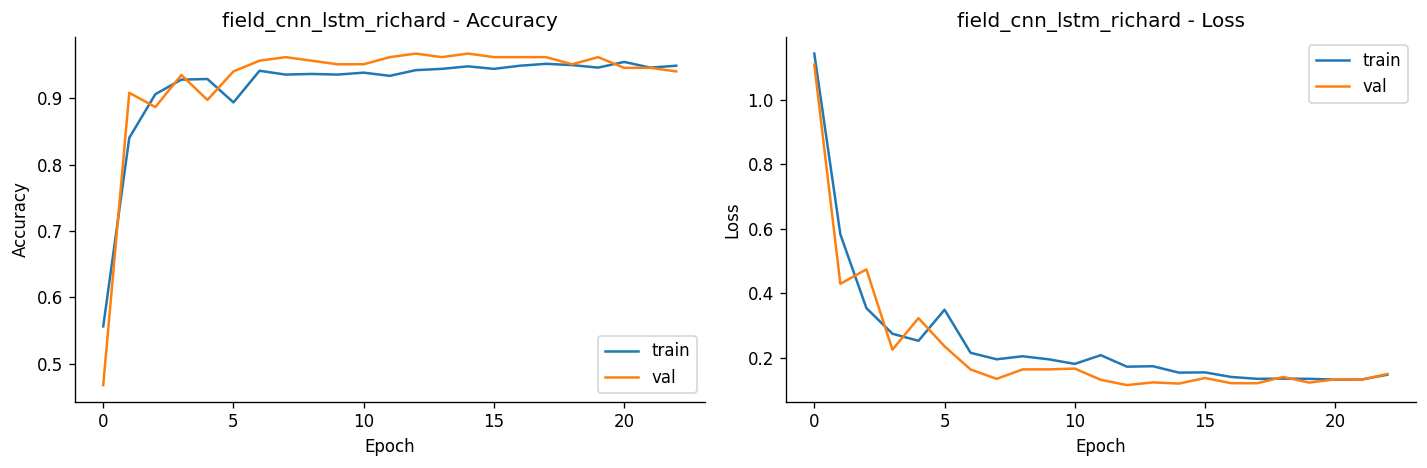


LOSO Summary
  TCN       : imaan=0.4514, richard=0.1415  ->  Mean = 0.2964
  LSTM      : imaan=0.4287, richard=0.2840  ->  Mean = 0.3563
  CNN_LSTM  : imaan=0.4133, richard=0.2350  ->  Mean = 0.3242


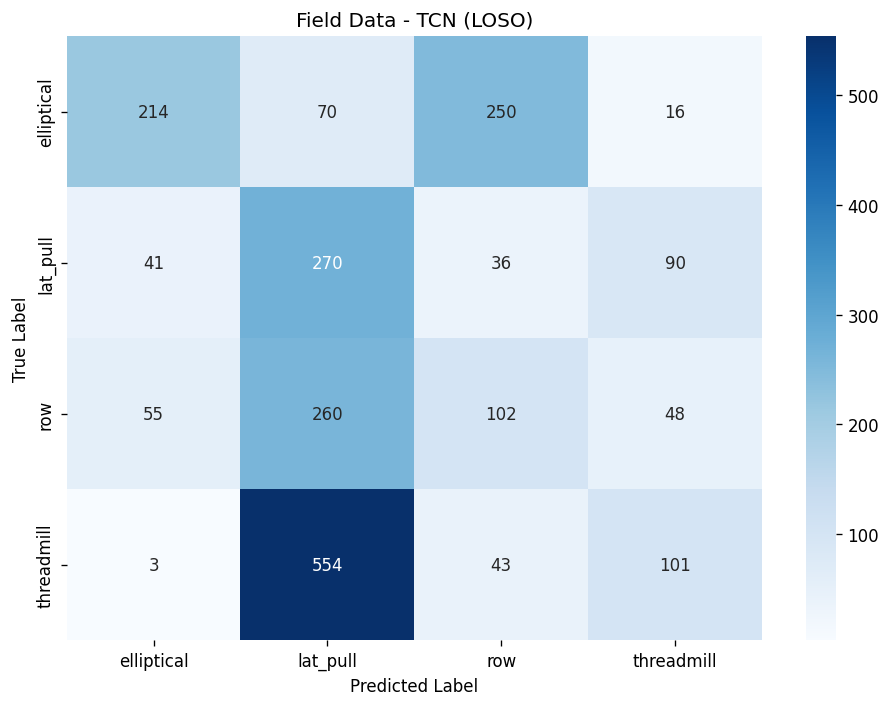

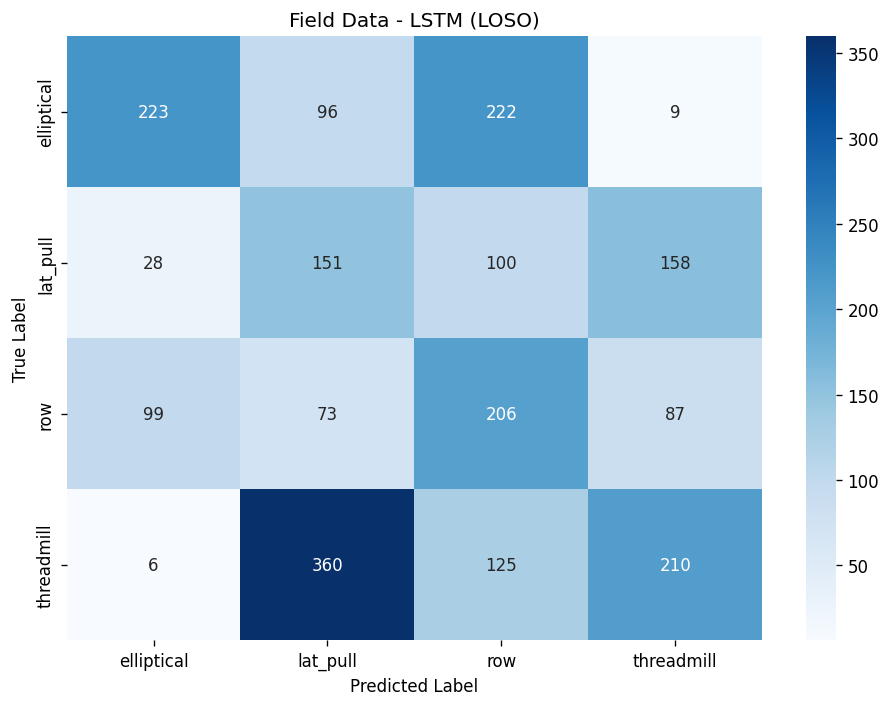

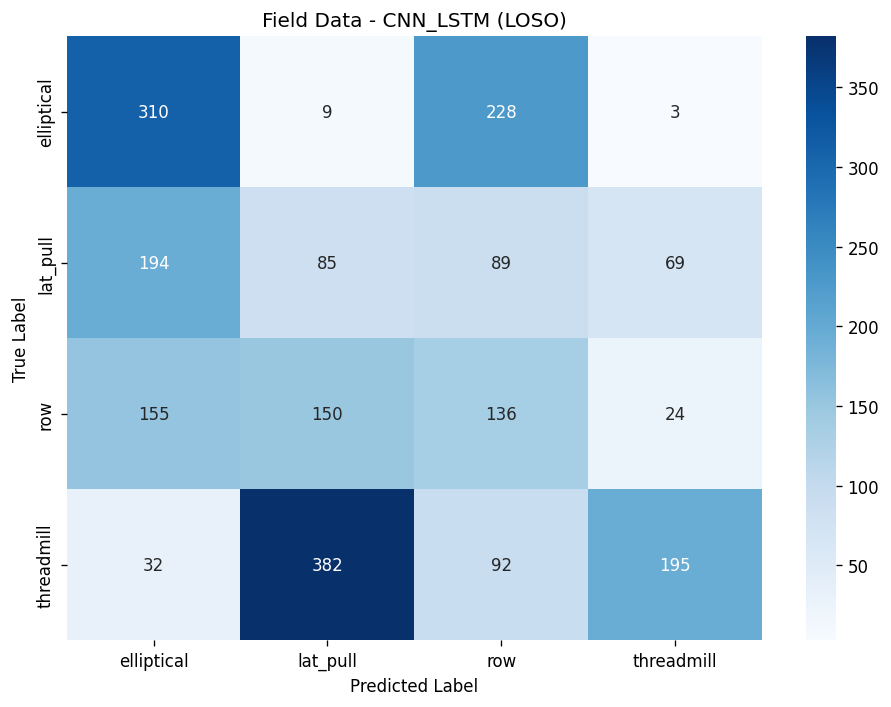


Results saved to: ./Models/Gym Models/dl_loso_results_20260610_180815.json

Model Comparison (mean LOSO accuracy)
  TCN         : 0.2964
  LSTM        : 0.3563
  CNN_LSTM    : 0.3242

  (RF model from cell 1 is available — re-run training.py with LOSO for RF accuracy)

Deep Learning Pipeline Complete

=== Deep Learning LOSO Summary ===
  TCN       : mean LOSO accuracy = 0.2964
  LSTM      : mean LOSO accuracy = 0.3563
  CNN_LSTM  : mean LOSO accuracy = 0.3242


In [22]:
# ── 7. DEEP LEARNING – LOSO EVALUATION (Point 6) ─────────────────────────────
# TCN, LSTM, CNN-LSTM trained on raw sequences with LOSO split.
# Uses Python.posthoc.get_training_summary which:
#   - reloads raw data
#   - handles missing values
#   - creates windows and sequences
#   - runs LOSO evaluation for all three DL models
#   - saves results + plots

from Python.posthoc import get_training_summary

dl_results, dl_summary = get_training_summary(rf_model=rf_model)

print("\n=== Deep Learning LOSO Summary ===")
for mt, s in dl_summary.items():
    print(f"  {mt.upper():10s}: mean LOSO accuracy = {s['mean']:.4f}")


=== Per-Activity Classification Report (RF LOSO, all folds) ===
              precision    recall  f1-score   support

  elliptical       0.84      0.20      0.33       550
    lat_pull       0.10      0.03      0.05       437
         row       0.43      0.56      0.49       465
  threadmill       0.51      0.92      0.65       701

    accuracy                           0.48      2153
   macro avg       0.47      0.43      0.38      2153
weighted avg       0.49      0.48      0.41      2153



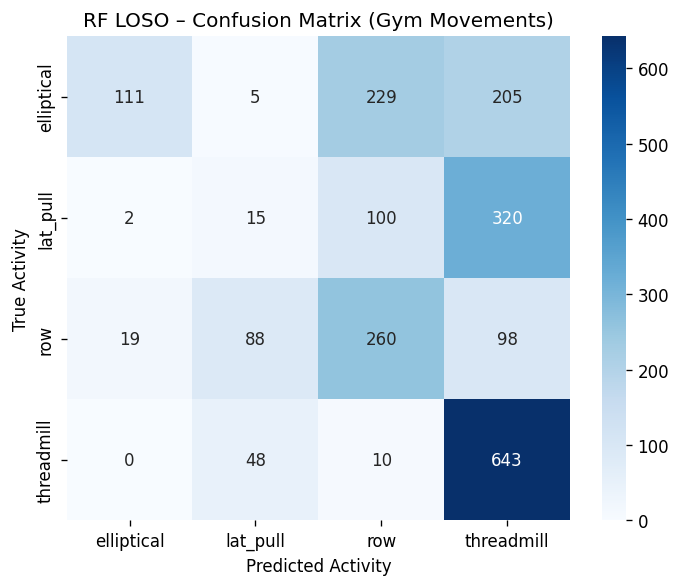


Samples per activity (windows):
  elliptical     : 550
  lat_pull       : 437
  row            : 465
  threadmill     : 701


In [21]:
# ── 8. PER-ACTIVITY ACCURACY BREAKDOWN ───────────────────────────────────────
# Analyse which gym movement is hardest to classify by looking at per-class
# precision / recall from the aggregated LOSO predictions of the best classical model.

import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Use the RF LOSO predictions (all folds combined)
rf_res = classical_results["rf"]
y_true_all = np.array(rf_res["all_true"])
y_pred_all = np.array(rf_res["all_pred"])
activities = sorted(set(y_true_all))

print("=== Per-Activity Classification Report (RF LOSO, all folds) ===")
print(classification_report(y_true_all, y_pred_all, target_names=activities, zero_division=0))

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_true_all, y_pred_all, labels=activities)
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=activities, yticklabels=activities, ax=ax,
)
ax.set_title("RF LOSO – Confusion Matrix (Gym Movements)")
ax.set_ylabel("True Activity")
ax.set_xlabel("Predicted Activity")
plt.tight_layout()
plt.savefig("./Plots/gym_rf_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# Per-activity sample counts
print("\nSamples per activity (windows):")
unique, counts = np.unique(y_true_all, return_counts=True)
for act, cnt in zip(unique, counts):
    print(f"  {act:<15s}: {cnt}")


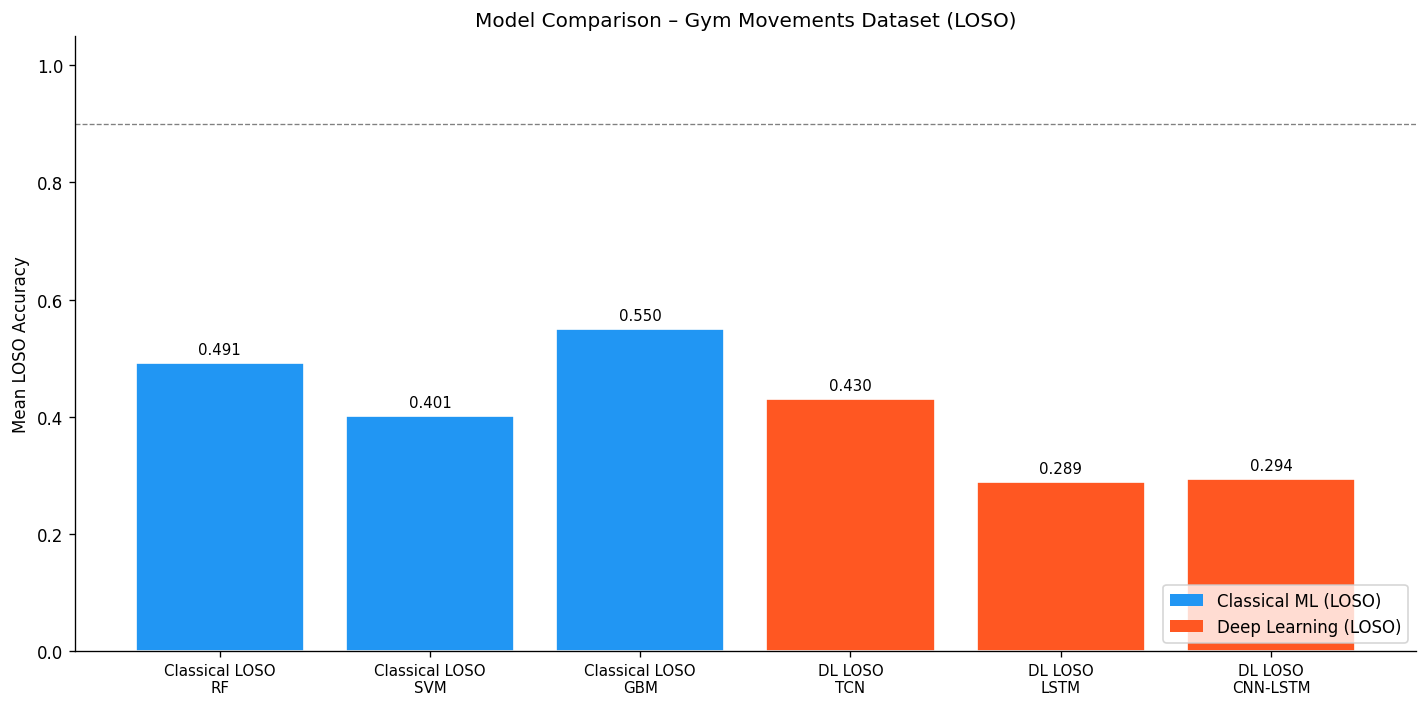


=== Final Results Table ===
Model                            Mean LOSO Accuracy
----------------------------------------------------
Classical LOSO – RF                                    0.4911
Classical LOSO – SVM                                   0.4007
Classical LOSO – GBM                                   0.5503
DL LOSO – TCN                                          0.4296
DL LOSO – LSTM                                         0.2889
DL LOSO – CNN-LSTM                                     0.2944


In [20]:
# ── 9. MODEL COMPARISON VISUALISATION ────────────────────────────────────────

# Collect results
all_accs = {}

# Classical LOSO
for mt, res in classical_results.items():
    all_accs[f"Classical LOSO\n{mt.upper()}"] = res["mean_accuracy"]

# Deep learning LOSO
for mt, s in dl_summary.items():
    label = {"tcn": "TCN", "lstm": "LSTM", "cnn_lstm": "CNN-LSTM"}.get(mt, mt.upper())
    all_accs[f"DL LOSO\n{label}"] = s["mean"]

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
colors = (
    ["#2196F3"] * len(classical_results)
    + ["#FF5722"] * len(dl_summary)
)
bars = ax.bar(list(all_accs.keys()), list(all_accs.values()), color=colors, edgecolor="white")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Mean LOSO Accuracy")
ax.set_title("Model Comparison – Gym Movements Dataset (LOSO)")
ax.axhline(0.9, color="gray", linestyle="--", linewidth=0.8, label="0.90 reference")

for bar, val in zip(bars, all_accs.values()):
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
        f"{val:.3f}", ha="center", va="bottom", fontsize=9,
    )

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#2196F3", label="Classical ML (LOSO)"),
    Patch(facecolor="#FF5722", label="Deep Learning (LOSO)"),
]
ax.legend(handles=legend_elements, loc="lower right")
plt.xticks(rotation=0, ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("./Plots/gym_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n=== Final Results Table ===")
print(f"{'Model':<30} {'Mean LOSO Accuracy':>20}")
print("-" * 52)
for name, acc in all_accs.items():
    label = name.replace("\n", " – ")
    print(f"{label:<50} {acc:>10.4f}")
